In [1]:
import os
# manually specify the GPUs to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import sys
import torch
import tqdm 
import pickle as pkl
import numpy as np

module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from torch.utils.data import DataLoader
from datasets import TransformerConf4Dataset
from models import TransformerConf3
from utils import args_transformer, create_mask_src, create_mask_tgt



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.multiprocessing.set_sharing_strategy('file_system')

In [2]:
# check which GPU is being used
print(f"Using GPU: {device}")
# check the used gpu index
print(f"Using GPU index: {torch.cuda.current_device()}")


Using GPU: cuda
Using GPU index: 0


In [3]:
parser = args_transformer()
args = parser.parse_args([
    "--metadata_path", "/pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/metadata.pkl",
    "--dataset_path", "/pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/{}/{}/{}/{}.zip",
    "--checkpoint_path", "/pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints",
    "--checkpoint_name", "v4",
    "--batch_size", "512",
    "--num_workers", "32",
    "--encoder_layers", "10",
    "--decoder_layers", "10",
])
print("\n- Arguments:")
for arg, value in vars(args).items():
    print(f"  {arg}: {value}")


- Arguments:
  dataset_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/{}/{}/{}/{}.zip
  metadata_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/metadata.pkl
  event_in_folder: 100000
  seed: 42
  max_p: 5
  max_p_contained: 5
  max_p_exiting: 1
  mom_smearing_p: 0.07
  mom_smearing_mu: 0.07
  cube_size: 10.27
  va_size: 7
  pad_value: -10000
  hidden: 192
  dropout: 0.1
  encoder_layers: 10
  decoder_layers: 10
  attn_heads: 16
  batch_size: 512
  epochs: 12420
  num_workers: 32
  lr: 0.002
  accum_grad_batches: 4
  cosine_annealing_steps: 400
  weight_decay: 0.01
  beta1: 0.9
  beta2: 0.999
  eps: 1e-09
  warmup_steps: 20
  save_dir: logs
  name: v1
  log_every_n_steps: 50
  early_stop_patience: 0
  save_top_k: 1
  checkpoint_path: /pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints
  checkpoint_name: v4
  load_checkpoint: None
  gpus: [0]
  num_nodes: 1


In [4]:
test_set = TransformerConf4Dataset(args, split="test")
test_loader = DataLoader(test_set, batch_size=args.batch_size, num_workers=args.num_workers,
            collate_fn=test_set.collate_fn, pin_memory=True, persistent_workers=True, shuffle=False)

In [5]:
model = TransformerConf3(
    num_encoder_layers=args.encoder_layers,
    num_decoder_layers=args.decoder_layers,
    emb_size=args.hidden,
    num_head=args.attn_heads,
    img_size=args.va_size,
    dropout=args.dropout,
    max_len=10,
)
checkpoint_path = "/".join((args.checkpoint_path, args.checkpoint_name, "val_loss", "last.ckpt"))
checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = {
    key.replace("model.", ""): value for key, value in checkpoint['state_dict'].items()
    if key.replace("model.", "") != "pos_encoding_tgt.pos_embedding"
}
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
print("Model weights loaded!")


/global/homes/b/botaoli/.conda/envs/env_nn/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model weights loaded!


In [6]:
@torch.inference_mode()
def eval_batch(batch, model, test_set):
    model.eval()

    pad_value = test_set.pad_value
    
    hits, exit_particle, vtx_true, ekin_true, dir_true, keep_iter_true, _, _ = batch
    

    # Create masks for source and target sequences
    src_mask, src_padding_mask = create_mask_src(hits, exit_particle, pad_value, device)
    
    hits = hits.to(device)
    exit_particle = exit_particle.to(device)
    src_mask = src_mask.to(device)
    src_padding_mask = src_padding_mask.to(device)

    memory, vtx_pred = model.encode(hits, exit_particle, src_mask, src_padding_mask)
    #memory = memory.to(device)

    L, B, _ = ekin_true.shape
    preds = torch.zeros(L+5, B, 4).fill_(pad_value).type(torch.float).to(device)
    
    first_token = model.first_token.repeat(1, B, 1)
    preds[0, :, :] = first_token

    # keep track of predictions that finished (none before starting)
    prev_info = torch.ones(size=(B,)).bool().to(device)

    L_pred = 1
    for i in range(L+4):
        # create masks and run model
        tgt_mask, tgt_padding_mask = create_mask_tgt(preds[:i+1], pad_value, device)
        out_ekin, out_dir, is_next = model.decode(
            preds[:i+1], memory, tgt_mask, tgt_padding_mask, src_padding_mask)

        ekin_last = out_ekin[-1].reshape(out_ekin.shape[1], out_ekin.shape[2])
        dir_last = out_dir[-1].reshape(out_dir.shape[1], out_dir.shape[2])
        is_next_last = torch.sigmoid(is_next[-1]).squeeze() > 0.5
        
        preds[i+1, prev_info, :1] = ekin_last.detach()[prev_info, :]
        preds[i+1, prev_info, 1:] = dir_last.detach()[prev_info, :]

        prev_info = torch.logical_and(prev_info, is_next_last)
        L_pred += 1
        if prev_info.sum() == 0:
            break

    ekin_pred = preds[1:L_pred, :, :1]
    dir_pred = preds[1:L_pred, :, 1:]

    output = {
        'ekin_pred': ekin_pred.detach().cpu().numpy(),
        'dir_pred': dir_pred.detach().cpu().numpy(),
        'vtx_pred': vtx_pred.detach().cpu().numpy(),
        'ekin_true': ekin_true.detach().cpu().numpy(),
        'dir_true': dir_true.detach().cpu().numpy(),
        'vtx_true': vtx_true.detach().cpu().numpy(),
    }

    return output


In [7]:
def test(loader, disable=False):

    pad_value = loader.dataset.pad_value
    stats = loader.dataset.metadata['statistics']['per_tree']['proton_contained']
    
    batch_size = loader.batch_size
    n_batches = len(loader)
    print(f"Number of batches: {n_batches}")

    t = tqdm.tqdm(enumerate(loader),total=n_batches, disable=disable)

    result = {
        'event_id':  [],
        'ekin_pred': [],
        'dir_pred':  [],
        'vtx_pred':  [],
        'N_pred':    [],
        'ekin_true': [],
        'dir_true':  [],
        'vtx_true':  [],
        'N_true':    [],
    }

    event_id = 0
    for i, data in t:        
        #(torch.Size([5, 10, 1]), torch.Size([5, 10, 3]), torch.Size([10, 3]))
        out = eval_batch(data, model, test_set)
        out['ekin_pred'] = (out['ekin_pred'] * stats['true_iniekin']['std']) + stats['true_iniekin']['mean']  # back to original values
        out['ekin_true'] = (out['ekin_true'] * stats['true_iniekin']['std']) + stats['true_iniekin']['mean']  # back to original values
        out['vtx_pred'] *= (loader.dataset.cube_size * 1.5)
        out['vtx_true'] *= (loader.dataset.cube_size * 1.5)
        
        for event_idx in range(out['ekin_pred'].shape[1]):
            ekin_pred = out['ekin_pred'][:, event_idx]
            dir_pred = out['dir_pred'][:, event_idx]
            vtx_pred = out['vtx_pred'][event_idx]
            ekin_true = out['ekin_true'][:, event_idx]
            dir_true = out['dir_true'][:, event_idx]
            vtx_true = out['vtx_true'][event_idx]
            
            # remove padding
            mask_pred = (dir_pred != pad_value)[:, 0]
            ekin_pred = ekin_pred[mask_pred].reshape(-1, ekin_pred.shape[1])
            dir_pred = dir_pred[mask_pred].reshape(-1, dir_pred.shape[1])
            mask_true = (dir_true != pad_value)[:, 0]
            ekin_true = ekin_true[mask_true].reshape(-1, ekin_true.shape[1])
            dir_true = dir_true[mask_true].reshape(-1, dir_true.shape[1])

            # min between
            N_pred, N_true = ekin_pred.shape[0], ekin_true.shape[0]
            N_min = min(N_pred, N_true)

            result['event_id'].append(event_id)
            result['ekin_pred'].append(ekin_pred[:N_min])
            result['dir_pred'].append(dir_pred[:N_min])
            result['vtx_pred'].append(vtx_pred)
            result['N_pred'].append(N_pred)
            result['ekin_true'].append(ekin_true[:N_min])
            result['dir_true'].append(dir_true[:N_min])
            result['vtx_true'].append(vtx_true)
            result['N_true'].append(N_true)
            
            event_id += 1

    return result

result = test(test_loader, disable=False)
    
with open("/pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints/v4/val_loss/sfgd_results_lastckpt.p", "wb") as fd:
    pkl.dump(result, fd)

# stop the network and free the memory
torch.cuda.empty_cache()


Number of batches: 245


  0%|          | 0/245 [00:00<?, ?it/s]/global/homes/b/botaoli/.conda/envs/env_nn/lib/python3.11/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████| 245/245 [02:22<00:00,  1.72it/s]


In [8]:
with open("/pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints/v4/val_loss/sfgd_results_lastckpt.p", "rb") as fd:
    result = pkl.load(fd)

import pandas as pd
df = pd.DataFrame(result, columns = result.keys())
df

,event_id,ekin_pred,dir_pred,vtx_pred,N_pred,ekin_true,dir_true,vtx_true,N_true
0,0,"[[66.55294758247439], [20.052811084289424], [1...","[[-0.026081288, 0.9984482, -0.04920211], [-0.0...","[-9.465657, -4.271293, -14.374949]",4,"[[65.26092466774887], [19.49731475987849], [12...","[[-0.027476188, 0.9966424, -0.0771303], [-0.29...","[-9.93056, -4.0523295, -14.225732]",4
1,1,"[[58.9484006969947], [37.02848146983437]]","[[0.20884022, 0.7168821, -0.665181], [0.165374...","[-4.318263, -8.630267, -9.174095]",2,"[[58.323730076963315], [37.35272209969101]]","[[0.060956955, 0.74570036, -0.6634872], [0.157...","[-4.8672357, -8.914055, -9.564947]",2
2,2,"[[54.1467559230106], [47.29909687275523], [25....","[[-0.23752171, -0.62829286, 0.7408317], [0.650...","[-11.686118, -0.77440864, -14.162366]",3,"[[54.33148246477243], [51.57733127059511], [26...","[[-0.20511383, -0.62420905, 0.75385106], [0.67...","[-12.012103, -0.4791537, -14.291951]",4
3,3,"[[68.03242033233364], [63.409291404838946], [5...","[[-0.14232948, -0.7633792, 0.630075], [-0.7242...","[13.868053, -13.912609, -2.4520538]",5,"[[70.42553685667286], [63.68554704363816], [59...","[[-0.107324876, -0.7640028, 0.6362241], [-0.69...","[12.864171, -13.480227, -2.9723353]",5
4,4,"[[75.12188271625953], [32.5663586700374], [27....","[[0.74385405, 0.32837015, -0.5821119], [0.7322...","[11.963364, 5.308191, 2.3217435]",4,"[[74.57543935932955], [32.9699705775594], [25....","[[0.7527749, 0.28886926, -0.59151036], [0.5756...","[12.249846, 5.839774, 2.3445745]",4
...,...,...,...,...,...,...,...,...,...
124995,124995,"[[44.591274715577086], [34.119090655574965]]","[[0.33686143, 0.17015302, 0.92605203], [-0.739...","[12.068184, -5.016497, -12.997327]",2,"[[44.85491925868637], [31.735229362738984]]","[[0.41925433, -0.32018486, 0.84953374], [-0.80...","[11.363436, -5.032085, -13.617096]",2
124996,124996,"[[72.19307587784812], [67.46967423081033], [39...","[[-0.5194488, -0.81873655, -0.24462892], [-0.3...","[-2.8427548, 3.1731691, -13.715901]",5,"[[70.96514818440576], [69.2465200409847], [42....","[[-0.5128089, -0.81602824, -0.26669252], [-0.3...","[-2.738963, 3.001797, -13.867996]",5
124997,124997,"[[67.51271019800882], [19.390939748003017], [6...","[[0.54941976, -0.26145002, 0.79358786], [0.533...","[-13.836337, 3.007996, -3.8118052]",3,"[[67.81774813937749], [18.531066475760294], [9...","[[0.56430876, -0.30628908, 0.76664376], [0.335...","[-14.455055, 3.4245162, -3.3796482]",3
124998,124998,"[[78.94400381193094], [34.611126312498136], [2...","[[0.66592497, -0.049147412, 0.7443981], [-0.97...","[-7.9276834, 12.9647, 6.5939703]",3,"[[79.77715972541341], [31.68298311159775], [25...","[[0.678466, -0.07318604, 0.73097724], [-0.9753...","[-7.914607, 13.2806, 6.683816]",3


In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_voxels(x, y, z, values, cmap='viridis', eps=1e-6):
    """
    Plot non-empty voxels in a 9×9×9 grid with opacity scaled logarithmically.

    Parameters:
    - x, y, z: sequences of relative positions in [-4, 4].
    - values: sequence of the same length as x, y, z containing positive scalar values.
    - cmap: colormap name for mapping values to colors.
    - eps: small offset added to values to avoid log(0) issues.
    """
    # Convert positions to 0–8 index space
    x_idx = np.array(x, int)
    y_idx = np.array(y, int)
    z_idx = np.array(z, int)
    vals = np.array(values, float)
    
    # Offset to ensure positivity for log
    vals_offset = vals + eps
    
    # Compute log-scaled values and normalize
    log_vals = np.log(vals_offset)
    norm_color = plt.Normalize(vals.min(), vals.max())
    norm_alpha = plt.Normalize(log_vals.min(), log_vals.max())
    cmap_obj = plt.cm.get_cmap(cmap)
    
    # Prepare masks and color array (RGBA)
    mask = np.zeros((9, 9, 9), bool)
    colors = np.zeros((9, 9, 9, 4), float)
    
    for xi, yi, zi, v, lv in zip(x_idx, y_idx, z_idx, vals, log_vals):
        mask[xi, yi, zi] = True
        r, g, b, _ = cmap_obj(norm_color(v))
        a = norm_alpha(lv)
        colors[xi, yi, zi] = (r, g, b, a)
    
    # Plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(mask, facecolors=colors, edgecolor='k')
    
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_zticks(range(9))
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('9×9×9 Voxel Plot with Log-Scaled Opacity')
    plt.show()

import numpy as np
import plotly.graph_objects as go
from matplotlib import cm, colors

def plot_voxels_plotly(x, y, z, values, cmap='viridis', eps=1e-6):
    """
    Plot non-empty voxels in a 9×9×9 grid using Plotly mesh3d,
    with opacity scaled by the square root of each value and
    an added colorbar.
    
    Parameters:
    - x, y, z: sequences of relative positions in [-4, 4].
    - values: sequence of the same length containing scalar values.
    - cmap: Matplotlib colormap name for mapping values to colors.
    - eps: small offset to avoid sqrt(0) issues.
    """
    xi = np.array(x, int)
    yi = np.array(y, int)
    zi = np.array(z, int)
    vals = np.array(values, float)

    sqrt_vals = np.sqrt(vals + eps)
    sv_min, sv_max = sqrt_vals.min(), sqrt_vals.max()
    v_min, v_max = vals.min(), vals.max()

    cube_verts = np.array([[-0.5,-0.5,-0.5],[0.5,-0.5,-0.5],[0.5,0.5,-0.5],[-0.5,0.5,-0.5],
                           [-0.5,-0.5, 0.5],[0.5,-0.5, 0.5],[0.5,0.5, 0.5],[-0.5,0.5, 0.5]])
    faces = np.array([[0,1,2],[0,2,3],[4,5,6],[4,6,7],
                      [0,1,5],[0,5,4],[2,3,7],[2,7,6],
                      [0,3,7],[0,7,4],[1,2,6],[1,6,5]])

    Xs, Ys, Zs = [], [], []
    I, J, K = [], [], []
    face_colors = []
    vert_count = 0

    cmap_obj = matplotlib.colormaps[cmap]
    norm_color = colors.Normalize(vmin=v_min, vmax=v_max)

    for x0, y0, z0, v, sv in zip(xi, yi, zi, vals, sqrt_vals):
        verts = cube_verts + np.array([x0, y0, z0])
        Xs.extend(verts[:,0]); Ys.extend(verts[:,1]); Zs.extend(verts[:,2])
        for tri in faces:
            I.append(vert_count + tri[0])
            J.append(vert_count + tri[1])
            K.append(vert_count + tri[2])
        r, g, b, _ = cmap_obj(norm_color(v))
        r, g, b = int(r*255), int(g*255), int(b*255)
        frac_sv = (sv - sv_min) / (sv_max - sv_min) if sv_max > sv_min else 1.0
        a = frac_sv * 0.8 + 0.2  # map to [0.2, 1]
        rgba = f'rgba({r},{g},{b},{a})'
        face_colors += [rgba] * len(faces)
        vert_count += len(verts)

    mesh = go.Mesh3d(
        x=Xs, y=Ys, z=Zs,
        i=I, j=J, k=K,
        facecolor=face_colors,
        flatshading=True,
        showscale=False
    )

    colorbar = go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(
            colorscale=cmap,
            cmin=v_min,
            cmax=v_max,
            color=[v_min, v_max],
            showscale=True,
            colorbar=dict(title='Value')
        ),
        hoverinfo='none'
    )

    fig = go.Figure(data=[mesh, colorbar])
    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=10, range=[0, 9]),
            yaxis=dict(nticks=10, range=[0, 9]),
            zaxis=dict(nticks=10, range=[0, 9]),
            aspectmode='cube'
        ),
        title='9×9×9 grid'
    )
    fig.show()



In [8]:
pad_value = test_loader.dataset.pad_value
stats = test_loader.dataset.metadata['statistics']['per_tree']['proton_contained']
    
batch_size = test_loader.batch_size
n_batches = len(test_loader)
print(f"Number of batches: {n_batches}")

t = tqdm.tqdm(enumerate(test_loader),total=n_batches, disable=False)

Number of batches: 489


  0%|          | 0/489 [00:00<?, ?it/s]

In [ ]:
#restart the test_loader
#test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)




for i, data in t: 
    
    hits, _, _, _, _, _, exit_images, contained_images = data
    print(exit_images[0].shape)
    print(contained_images[0].shape)
    
    out = eval_batch(data, model, test_set)

    check_eve = 0
    
    for event_idx in range(out['ekin_pred'].shape[1]):
        ekin_pred = out['ekin_pred'][:, event_idx]
        ekin_true = out['ekin_true'][:, event_idx]
        
        # remove padding
        mask_pred = (ekin_pred != pad_value)[:, 0]
        ekin_pred = ekin_pred[mask_pred].reshape(-1, ekin_pred.shape[1])
        mask_true = (ekin_true != pad_value)[:, 0]
        ekin_true = ekin_true[mask_true].reshape(-1, ekin_true.shape[1])
        # min between
        N_pred, N_true = ekin_pred.shape[0], ekin_true.shape[0]
        print(N_pred, N_true)
        if abs(N_pred - N_true) > 2:
            check_eve = event_idx
            break
    

    # x = hits[check_eve,:,0].cpu().numpy().astype(int)
    # y = hits[check_eve,:,1].cpu().numpy().astype(int)
    # z = hits[check_eve,:,2].cpu().numpy().astype(int)
    # charge = hits[check_eve,:,3].cpu().numpy()

    print(hits.shape)
    eve_ind = 200
    

    x = hits[:,check_eve,0].cpu().numpy().astype(int)
    y = hits[:,check_eve,1].cpu().numpy().astype(int)
    z = hits[:,check_eve,2].cpu().numpy().astype(int)
    charge = hits[:,check_eve,3].cpu().numpy()

    x = x[x>-1]
    y = y[y>-1]
    z = z[z>-1]
    charge = charge[charge>-1]
    charge *= stats['recon_charge']['std']

    c_cut = 100
    
    x = x[charge>c_cut]
    y = y[charge>c_cut]
    z = z[charge>c_cut]
    charge = charge[charge>c_cut]

    print(x)
    print(y)
    print(z)
    print(charge)

    # plot the hits
    plot_voxels_plotly(x, y, z, charge)

    break



(20, 7, 7, 7)
4 2
5 1
torch.Size([220, 256, 4])
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6]
[0 1 1 1 2 2 3 3 3 4 4 6 0 1 2 2 2 3 3 3 4 4 4 4 5 5 5 5 5 6 6 6 0 0 1 1 2
 2 2 2 2 3 3 3 3 3 4 4 5 5 6 1 1 1 2 2 2 3 3 4 4 5 5 5 6 0 0 1 1 1 2 2 2 3
 4 4 5 5 6 0 1 1 1 2 3 4 5 6 0 0 0 1 1 2 3 6]
[6 2 3 5 2 4 1 2 3 2 3 0 3 3 2 3 4 1 2 3 1 2 3 4 1 2 4 5 6 0 1 6 2 3 2 3 0
 1 2 3 6 1 2 3 4 5 2 3 2 3 2 0 2 3 0 1 2 2 3 2 3 2 3 4 4 3 4 1 2 3 1 2 3 2
 2 4 2 3 2 3 1 3 4 1 2 6 2 2 0 1 4 1 4 1 1 2]
[ 129.53201   416.86282   312.16553   191.37747   473.07767   214.9829
  177.1711    415.655     267.77075   110.96349   143.6008    213.97011
  327.49176   166.72319   855.9504    284.6692    220.94598   154.58241
 2616.208     576.2429    122.855446  416.4879    106.55616   117.10442
  320.9503    226.98209   158.73973   216.60426   105.62057   108.60014
  106

In [9]:
import matplotlib.pyplot as plt
x = []
x2 = []
y = []
y2 = []
z = []
z2 = []
charge = []
charge2 = []

for i, data in t: 
    hits, _, _, _, _, _ = data
    
    x_temp = hits[:,:,0].cpu().numpy().astype(int).reshape(-1)
    y_temp = hits[:,:,1].cpu().numpy().astype(int).reshape(-1)
    z_temp = hits[:,:,2].cpu().numpy().astype(int).reshape(-1)
    charge_temp = hits[:,:,3].cpu().numpy().reshape(-1)

    x = np.concatenate([x, x_temp])
    y = np.concatenate([y, y_temp])
    z = np.concatenate([z, z_temp])
    charge = np.concatenate([charge, charge_temp])

    for j in range(20,50):#range(hits.shape[0]):
        x2_temp = hits[:,j,0].cpu().numpy().astype(int).reshape(-1)
        y2_temp = hits[:,j,1].cpu().numpy().astype(int).reshape(-1)
        z2_temp = hits[:,j,2].cpu().numpy().astype(int).reshape(-1)
        charge2_temp = hits[:,j,3].cpu().numpy().reshape(-1)

        x2 = np.concatenate([x2, x2_temp])
        y2 = np.concatenate([y2, y2_temp])
        z2 = np.concatenate([z2, z2_temp])
        charge2 = np.concatenate([charge2, charge2_temp])
    break

# # draw histograms of x, y, z, charge
# plt.hist(x, bins=100)
# plt.show()
# plt.hist(y, bins=100)
# plt.show()
# plt.hist(z, bins=100)
# plt.show()





(20480,)
(2400,)


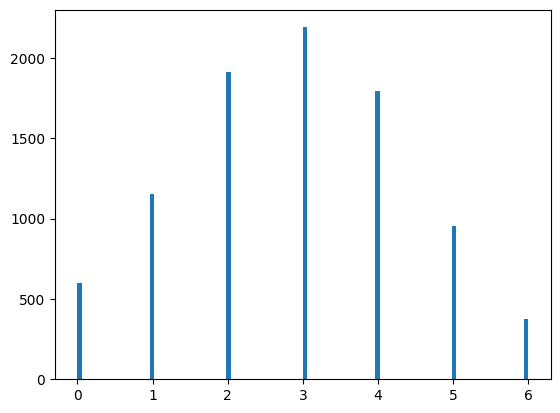

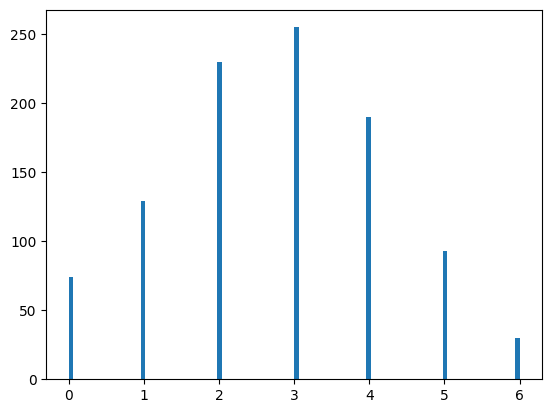

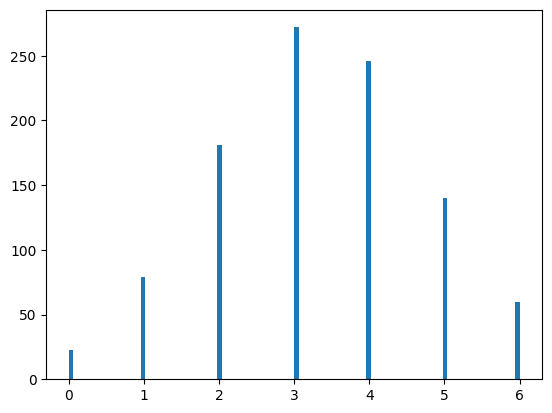

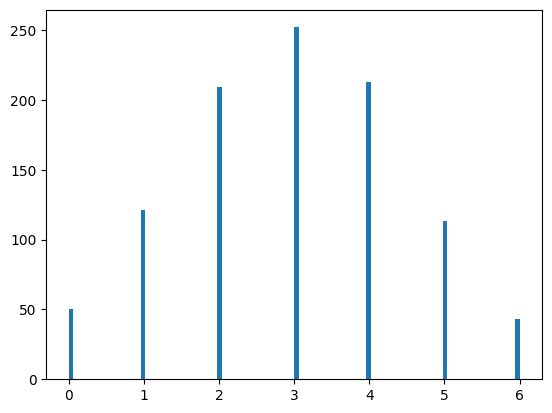

In [10]:
print(x.shape)
x = x[x>-1]
y = y[y>-1]
z = z[z>-1]

print(x2.shape)
x2 = x2[x2>-1]
y2 = y2[y2>-1]
z2 = z2[z2>-1]

#show hist
plt.hist(x, bins=100)
plt.show()

plt.hist(x2, bins=100)
plt.show()

plt.hist(y2, bins=100)
plt.show()

plt.hist(z2, bins=100)
plt.show()

# plt.hist(y, bins=100)
# plt.show()
# plt.hist(z, bins=100)
# plt.show()



In [10]:
PROTON_MASS_MEV = 938.2720813  # MeV/c^2

def _kinetic_to_pvec(T: np.ndarray, nvec: np.ndarray, m_mev: float = PROTON_MASS_MEV) -> np.ndarray:
    """
    Convert kinetic energies T [MeV] and unit directions nvec [...,3] to momentum vectors p_vec [...,3] in MeV/c.
    Shapes:
      T: (N,)
      nvec: (N, 3) (assumed normalized)
    Returns:
      p_vec: (N, 3)
    """
    T = np.asarray(T, dtype=np.float64)
    nvec = np.asarray(nvec, dtype=np.float64)
    # p = sqrt(T*(T+2m))
    p_mag = np.sqrt(np.clip(T*(T + 2.0*m_mev), a_min=0.0, a_max=None))
    return (p_mag[:, None] * nvec)

def _pairwise_p_distance(p_true: np.ndarray, p_pred: np.ndarray) -> np.ndarray:
    """
    Euclidean distances between all pairs of momentum vectors.
    p_true: (Nt, 3), p_pred: (Np, 3)
    Returns: (Nt, Np) distance matrix
    """
    # (Nt, 1, 3) - (1, Np, 3) -> (Nt, Np, 3)
    diff = p_true[:, None, :] - p_pred[None, :, :]
    return np.sqrt(np.sum(diff*diff, axis=2))

def _optimal_assignment(cost: np.ndarray):
    """
    Solve the linear sum assignment (Hungarian). Prefers SciPy if available;
    falls back to a greedy matcher (near-optimal) if SciPy isn't installed.
    Returns row_ind, col_ind
    """
    try:
        from scipy.optimize import linear_sum_assignment
        return linear_sum_assignment(cost)
    except Exception:
        # Greedy fallback: iteratively pick the global minimum remaining.
        # Note: not guaranteed optimal, but usually close.
        cost = cost.copy()
        Nt, Np = cost.shape
        row_ind, col_ind = [], []
        used_rows = set()
        used_cols = set()
        # Flatten indices by increasing cost
        order = np.argsort(cost, axis=None)
        for k in order:
            i, j = np.unravel_index(k, cost.shape)
            if i not in used_rows and j not in used_cols:
                row_ind.append(i); col_ind.append(j)
                used_rows.add(i); used_cols.add(j)
                if len(row_ind) == min(Nt, Np):
                    break
        return np.array(row_ind, dtype=int), np.array(col_ind, dtype=int)

def _safe_unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return v / n

def match_predictions_to_truth(
    df,
    ekin_true_col="ekin_true",
    dir_true_col="dir_true",
    ekin_pred_col="ekin_pred",
    dir_pred_col="dir_pred",
    mass_mev=PROTON_MASS_MEV,
    add_metrics=True,
):
    """
    For each row of `df`, reorders the predicted arrays so they align with the closest true entries
    under the Euclidean distance in momentum space.

    Adds these columns:
      - ekin_pred_reordered: (Nt,)
      - dir_pred_reordered: (Nt, 3)
      - pred_to_true_indices: indices into the *original* predicted arrays placed at each true index (len Nt),
                              with -1 where no prediction matched (when Np < Nt)
      - (optional) dE_MeV: per-match energy residual (pred - true) aligned to truths (NaN for unmatched)
      - (optional) ang_err_deg: angle between true and matched predicted *directions* in degrees (NaN for unmatched)
      - (optional) p_dist: Euclidean distance in momentum space [MeV/c] (NaN for unmatched)
    """
    new_cols = {
        "ekin_pred_reordered": [],
        "dir_pred_reordered": [],
        "pred_to_true_indices": [],
    }
    if add_metrics:
        new_cols.update({
            "dE_MeV": [],
            "ang_err_deg": [],
            "p_dist": [],
        })

    for _, row in df.iterrows():
        if _%10000 == 0:
            print(_, len(df))
        Tt = np.asarray(row[ekin_true_col]).reshape(-1)
        nt = _safe_unit(np.asarray(row[dir_true_col]))
        Tp = np.asarray(row[ekin_pred_col]).reshape(-1)
        npred = _safe_unit(np.asarray(row[dir_pred_col]))

        Nt, Np = len(Tt), len(Tp)

        # Momentum vectors
        p_true = _kinetic_to_pvec(Tt, nt, m_mev=mass_mev)   # (Nt,3)
        p_pred = _kinetic_to_pvec(Tp, npred, m_mev=mass_mev) # (Np,3)

        # Cost matrix in momentum space
        C = _pairwise_p_distance(p_true, p_pred)  # (Nt, Np)

        # Optimal (or greedy fallback) assignment
        r_idx, c_idx = _optimal_assignment(C)

        # Build outputs aligned to *true* ordering/length Nt
        ekin_pred_reordered = np.full((Nt,), np.nan, dtype=float)
        dir_pred_reordered  = np.full((Nt, 3), np.nan, dtype=float)
        pred_to_true_indices = np.full((Nt,), -1, dtype=int)
        if add_metrics:
            dE = np.full((Nt,), np.nan, dtype=float)
            ang_err = np.full((Nt,), np.nan, dtype=float)
            p_d = np.full((Nt,), np.nan, dtype=float)

        for ti, pj in zip(r_idx, c_idx):
            ekin_pred_reordered[ti] = Tp[pj]
            dir_pred_reordered[ti]  = npred[pj]
            pred_to_true_indices[ti] = pj
            if add_metrics:
                dE[ti] = Tp[pj] - Tt[ti]
                # angle between true and matched predicted directions
                dot = float(np.clip(np.dot(nt[ti], npred[pj]), -1.0, 1.0))
                ang_err[ti] = np.degrees(np.arccos(dot))
                p_d[ti] = C[ti, pj]

        new_cols["ekin_pred_reordered"].append(ekin_pred_reordered)
        new_cols["dir_pred_reordered"].append(dir_pred_reordered)
        new_cols["pred_to_true_indices"].append(pred_to_true_indices)
        if add_metrics:
            new_cols["dE_MeV"].append(dE)
            new_cols["ang_err_deg"].append(ang_err)
            new_cols["p_dist"].append(p_d)

    # Attach to a copy of the dataframe
    out = df.copy()
    for k, v in new_cols.items():
        out[k] = v
    return out

df_matched = match_predictions_to_truth(df)

0 125000
10000 125000
20000 125000
30000 125000
40000 125000
50000 125000
60000 125000
70000 125000
80000 125000
90000 125000
100000 125000
110000 125000
120000 125000


In [11]:
ekin_pred = np.concatenate(df_matched['ekin_pred_reordered']).reshape(-1, 1)
dir_pred = np.concatenate(df_matched['dir_pred_reordered'])
vtx_pred = np.stack(result['vtx_pred'])
N_pred = np.array(result['N_pred'])
ekin_true = np.concatenate(result['ekin_true'])
dir_true = np.concatenate(result['dir_true'])
vtx_true = np.stack(result['vtx_true'])
N_true = np.array(result['N_true'])

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(classification_report(N_true, N_pred, digits=3))
conf = confusion_matrix(N_pred, N_true)
print(conf)

              precision    recall  f1-score   support

           1      0.884     0.982     0.930     25059
           2      0.769     0.847     0.806     24948
           3      0.669     0.739     0.702     25158
           4      0.597     0.653     0.624     24806
           5      0.944     0.557     0.701     25029

    accuracy                          0.756    125000
   macro avg      0.773     0.756     0.753    125000
weighted avg      0.773     0.756     0.753    125000

[[24598  3038   172     6     1]
 [  459 21135  5313   529    42]
 [    1   767 18594  7249  1170]
 [    1     8  1074 16200  9866]
 [    0     0     5   822 13950]]


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import font_manager
#from matplotlib.patches import Rectangle, PathPatch
import matplotlib

# reset the plot configurations to default
plt.rcdefaults()

from pathlib import Path
font_path = str(Path(matplotlib.get_data_path(), "fonts/ttf/cmr10.ttf"))
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams["axes.formatter.use_mathtext"] = True
params = {'mathtext.default': 'regular' }

import scipy.stats as st

def plot_scatter(true, pred, label=None, labely=None, s=0.01, fontsize=15, save_path=None, save_name=None):
    if labely is None:
        labely = label
    
    diff = pred-true
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.scatter(true, pred, s=s)
    plt.xlabel("{0}{1}{2}".format(label[0], "$_{true}$", label[1]), fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(labely[0], "$_{reco}$", labely[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.grid()
    
    plt.savefig(save_path + save_name + ".png")
    plt.show()

    #save the plot as svg

def plot_scatter_hist(true, pred, label=None, labely=None, s=0.01, fontsize=15):
    if labely is None:
        labely = label
    
    diff = pred - true
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    
    # Create a 2x2 grid of subplots
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[7, 3], height_ratios=[3, 7])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_hist_x = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
    ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    # Scatter plot
    ax_scatter.scatter(true, pred, s=s)
    
    # Marginal histograms on the top
    ax_hist_x.hist(true, bins=30, color='skyblue')
    ax_hist_x.set(ylabel='Frequency')
    ax_hist_x.xaxis.set_tick_params(labelbottom=False)
    
    # Marginal histograms on the right
    ax_hist_y.hist(pred, bins=30, orientation='horizontal', color='skyblue')
    ax_hist_y.set(xlabel='Frequency')
    ax_hist_y.yaxis.set_tick_params(labelleft=False)
    
    # Set labels and title
    plt.xlabel("{0}{1}{2}".format(label[0], "$_{true}$", label[1]), fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(labely[0], "$_{reco}$", labely[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    
    # Adjust spacing between subplots
    fig.tight_layout()
    
    plt.grid()
    plt.show()

    
def plot_scatter_len(true, pred, label=None, labely=None, s=0.01, fontsize=15):
    diff = pred
    textstr = '\n'.join((
        r'$\mu \ (reco-true)=%.2f$' % (diff.mean(), ),
        r'$\sigma \ (reco-true)=%.2f$' % (diff.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.scatter(true, pred, s=s)
    plt.xlabel("particle length [mm]", fontsize=fontsize)
    plt.ylabel("{0}{1}{2}".format(label[0], "$_{reco-true}$", label[1]), fontsize=fontsize)
    plt.text(0.15, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.xlim(0, 35)
    plt.grid()
    plt.show()
    
def plot_hist(x, xlim, label=None):
    x = x[x<=xlim]
    textstr = '\n'.join((
        r'$\mu=%.2f$' % (x.mean(), ),
        r'$\sigma=%.2f$' % (x.std(), )))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.hist(x, bins=100, color="cornflowerblue")
    plt.ylabel("frequency", fontsize=15)
    plt.xlabel(label, fontsize=15)
    plt.xlim(0, xlim)
    plt.yscale("log")
    plt.ylim(1,40000)
    plt.yticks((1, 10, 100, 1000, 10000))
    plt.text(0.71, 0.84, textstr, transform=plt.gcf().transFigure, fontsize=14,
             verticalalignment='top', bbox=props)
    plt.show()
    
def plot_errorbars(true, pred, metric="chi2", xlim=None, ylim=None, xticks=None, yticks=None, 
                   xlabel=None, x2label=None, ylabel=None, loc=None):
    m_proton = 938.27208816  # mass of the proton in MeV
    bin_edges = np.histogram_bin_edges(np.concatenate((true, pred)), bins=12)
    true_binned = np.digitize(true, bin_edges)
    pred_binned = np.digitize(pred, bin_edges)
    
    if metric=="chi2":
        data = [(pred[true_binned == i]-true[true_binned == i])/(true[true_binned == i]+1e-4) for i in range(1, len(bin_edges))]
    else:
        data = [(pred[true_binned == i]-true[true_binned == i]) for i in range(1, len(bin_edges))]

    means = np.array([x.mean() for x in data])
    conf68 = np.array([st.norm(*st.norm.fit(x)).interval(0.68) for x in data]).T
    conf95 = np.array([st.norm(*st.norm.fit(x)).interval(0.95) for x in data]).T

    fig = plt.figure()
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twiny()
    data1 = {
            'x': np.arange(len(means)),
            'y1': conf68[0],#[y - e for y, e in zip(means, np.abs(conf68)[0])],
            'y2': conf68[1]}#[y + e for y, e in zip(means, np.abs(conf68)[1])]}
    ax1.fill_between(**data1, alpha=.10, zorder=-5, color="tab:blue")
    data2 = {
            'x': np.arange(len(means)),
            'y1': conf95[0],#[y - e for y, e in zip(means, np.abs(conf95)[0])],
            'y2': conf95[1]}#[y + e for y, e in zip(means, np.abs(conf95)[1])]}
    ax1.fill_between(**data2, alpha=.05, zorder=-10, color="tab:red")
    ax1.plot(means, marker="o", ls="--", color="tab:cyan", ms=5, label=r"$\mu$")
    
    ax1.errorbar(data1['x'],
                np.zeros(shape=means.shape), 
                np.abs(conf68),
                fmt=' ', lw=3, capsize=4, zorder=-5, ecolor="tab:blue", label="68% int.")
    ax1.errorbar(data2['x'],
                np.zeros(shape=means.shape), 
                np.abs(conf95),
                elinewidth=1, fmt=' ', lw=3, capsize=4, zorder=-10, ecolor="tab:red", label="95% int.")

    # find outliers
    outliers_x = []
    outliers_y = []
    for i, lims in enumerate(conf95.T):
        data_bin = data[i]
        outliers = data_bin[(data_bin<lims[0]) | (data_bin>lims[1])]
        outliers = np.random.choice(outliers, outliers.shape[0]//10)
        outliers_x.extend([xticks[i]+0.5]*outliers.shape[0])
        outliers_y.extend(outliers)
    outliers_x = np.array(outliers_x)
    outliers_y = np.array(outliers_y)
        
    ax1.scatter(outliers_x, outliers_y, s=5, linewidths=0.25, color="gray", facecolors='none')
    # calc p
    ps = [np.sqrt((ke**2 + 2*ke*m_proton)).round(1) for ke in np.arange(10, 71, 10)]

    ax1.set_xticks(xticks, np.arange(0, 61, 5), fontsize=15)
    ax1.set_xlabel(xlabel, fontsize=20)
    ax1.set_ylabel(ylabel, fontsize=20)
    ax1.set_ylim(ylim[0], ylim[1])
    ax1.set_yticks(yticks)
    ax1.set_xlim(xlim[0], xlim[1])
    ax2.set_xlim(xlim[0], xlim[1])
    ax2.set_xlabel(x2label, fontsize=20, labelpad=10)

    ticks = np.arange(-0.5, 11.7, 0.002)
    kes = np.arange(10, 71, 0.01)
    ps = []
    tk = []
    for i in range(len(ticks)):
        t = ticks[i]
        ke = kes[i]
        a = np.sqrt((ke**2 + 2*ke*m_proton)).round(1)
        if a%50==0 and a not in ps:
            ps.append(a)
            tk.append(t)
    ax2.set_xticks(tk, ps, fontsize=15)
    ax2.tick_params(axis='both', which='major', labelsize=15)
    ax1.grid(axis='y')
    ax1.tick_params(axis='both', which='major', labelsize=15)

    legend = ax1.legend(fontsize=15, loc=loc, edgecolor='black')
    legend.set_title("N = {}".format(len(true)), prop=FontProperties(size=15))
    
    plt.tight_layout()
    plt.savefig("../images_paper/ke_res_muon.pdf")
    
def plot_violins(variable, label):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a violin plot
    ax.violinplot(dataset=variable[nparticles_true==1], positions=[1], 
                  showmeans=True, showmedians=False, showextrema=False)
    ax.violinplot(dataset=variable[nparticles_true==2], positions=[2], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==3], positions=[3], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==4], positions=[4], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=variable[nparticles_true==5], positions=[5], 
                  showmeans=True, showmedians=False)

    # Add labels and title
    ax.set_xlabel("Number of protons per event", fontsize=15)
    ax.set_ylabel(label, fontsize=15)

    # Show the plot
    plt.show()
    
def plot_violins2(variable, label):
    # Create a figure and axis object
    fig, ax = plt.subplots()

    # Create a violin plot
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==1]), positions=[1], 
                  showmeans=True, showmedians=False, showextrema=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==2]), positions=[2], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==3]), positions=[3], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==4]), positions=[4], 
                  showmeans=True, showmedians=False)
    ax.violinplot(dataset=np.concatenate(variable[nparticles_true==5]), positions=[5], 
                  showmeans=True, showmedians=False)

    # Add labels and title
    ax.set_xlabel("Number of protons per event", fontsize=15)
    ax.set_ylabel(label, fontsize=15)

    # Show the plot
    plt.show()


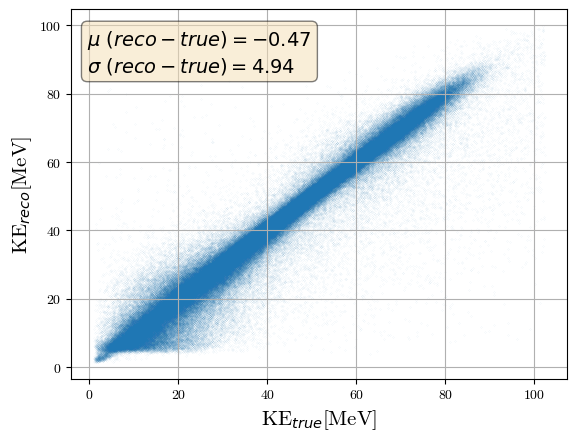

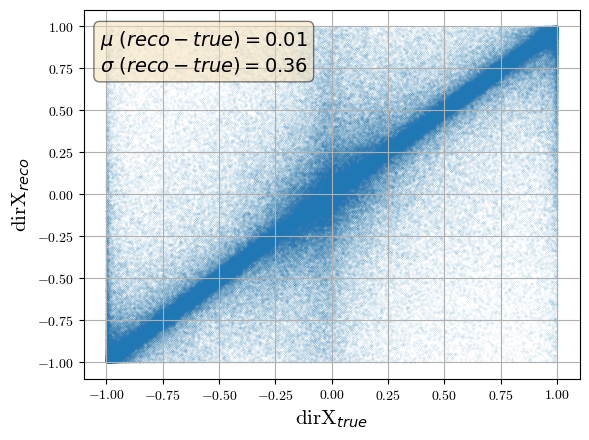

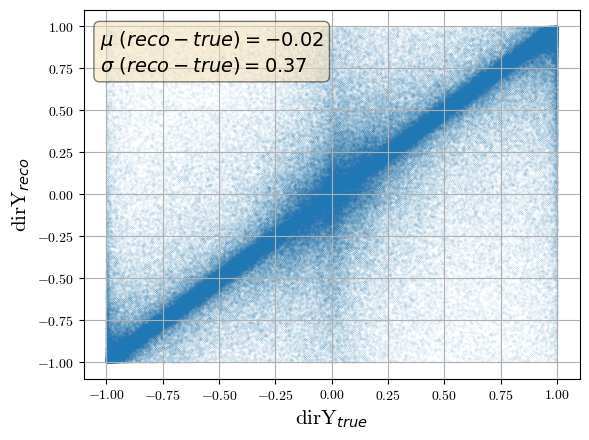

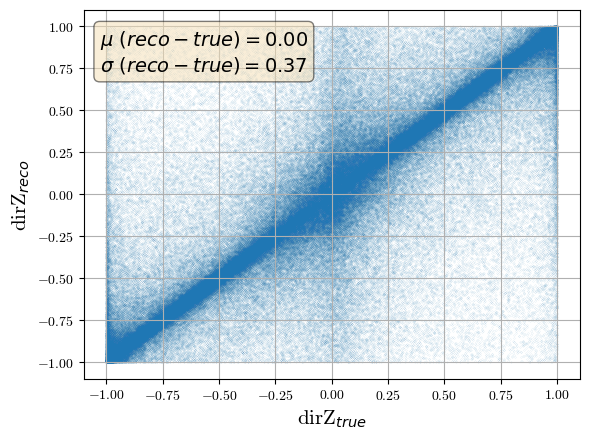

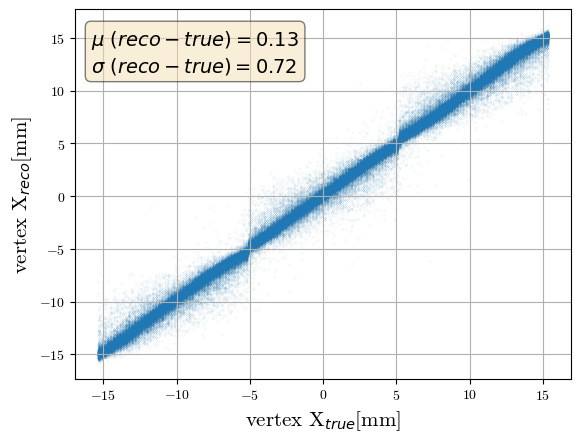

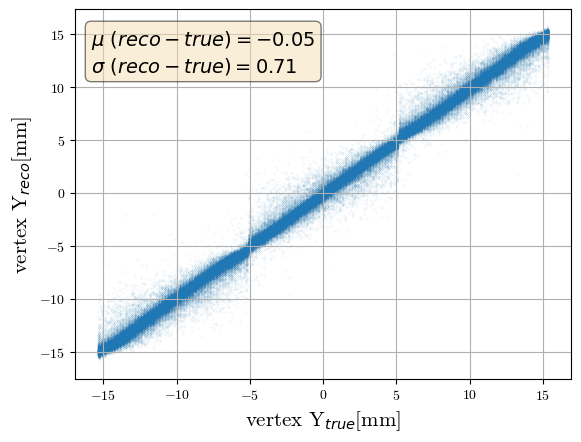

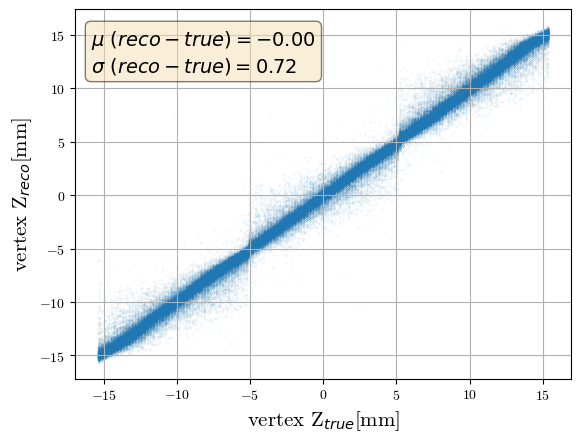

In [18]:
s = 0.0005
save_path = "/global/common/software/m5022/botaoli/SFGD_VA/Code/NeutrinoVertex-DL/output/"

plot_scatter(ekin_true, ekin_pred, label=("KE","[MeV]"), s=s, save_path=save_path, save_name="ekin")

plot_scatter(dir_pred[:,0], dir_true[:,0], label=("dirX", ""), s=s*3, save_path=save_path, save_name="dirX")
plot_scatter(dir_pred[:,1], dir_true[:,1], label=("dirY", ""), s=s*3, save_path=save_path, save_name="dirY")
plot_scatter(dir_pred[:,2], dir_true[:,2], label=("dirZ", ""), s=s*3, save_path=save_path, save_name="dirZ")

plot_scatter(vtx_true[:,0], vtx_pred[:,0], label=("vertex X", "[mm]"), s=s*3, save_path=save_path, save_name="vtxX")
plot_scatter(vtx_true[:,1], vtx_pred[:,1], label=("vertex Y", "[mm]"), s=s*3, save_path=save_path, save_name="vtxY")
plot_scatter(vtx_true[:,2], vtx_pred[:,2], label=("vertex Z", "[mm]"), s=s*3, save_path=save_path, save_name="vtxZ")






0.75588
[[24600  3034   174     6     1]
 [  457 21140  5314   530    42]
 [    1   766 18586  7249  1167]
 [    1     8  1079 16205  9865]
 [    0     0     5   816 13954]]


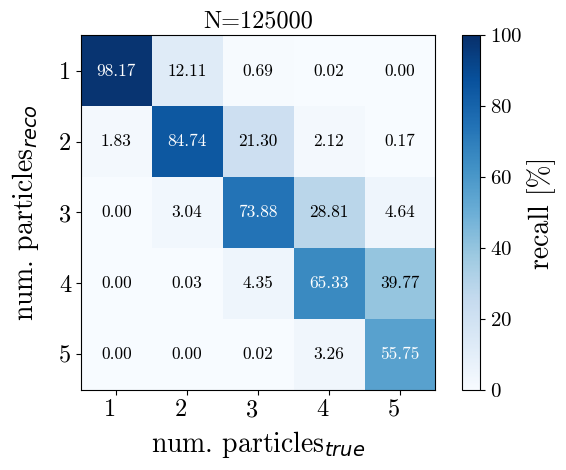

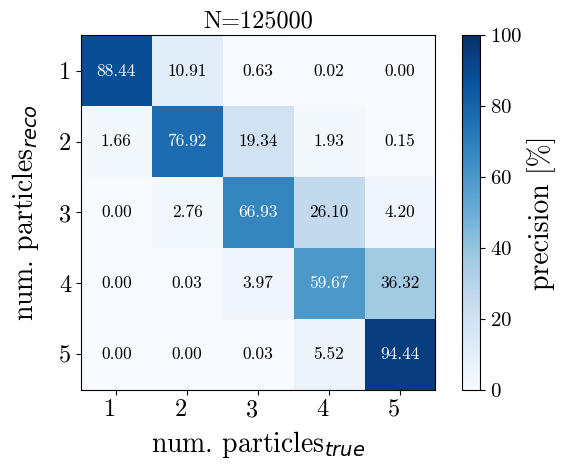

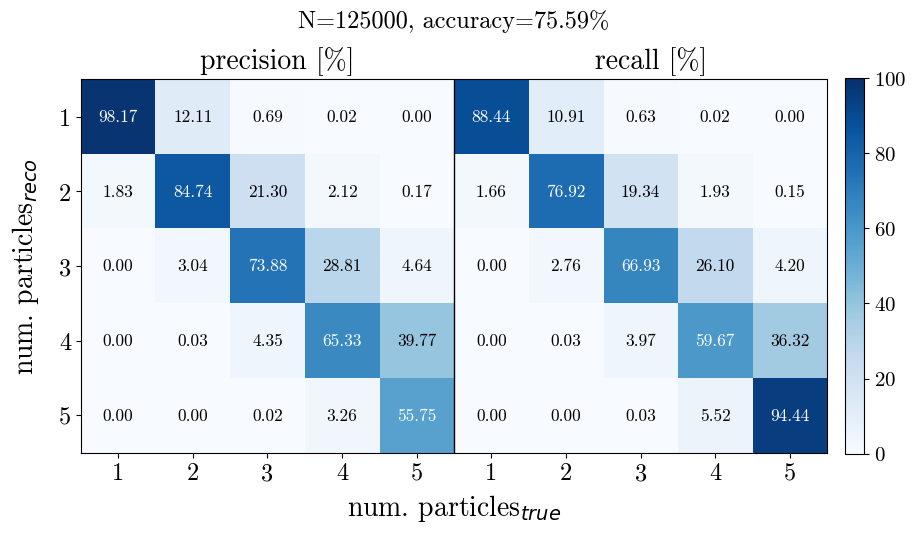

In [ ]:
def plot_confusion_matrix(confusion_matrix, labels, metric="precision", N=0, save_path=None, save_name=None):
    #confusion_matrix/=confusion_matrix.sum(axis=1)
    
    fig, ax = plt.subplots()
    im = ax.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=100)
    cbar = ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(confusion_matrix.shape[1]),
           yticks=np.arange(confusion_matrix.shape[0]),
           xticklabels=labels, yticklabels=labels,
           #title='N={}'.format(N),
          )
    cbar.set_label("{} [%]".format(metric), fontsize=20)
    cbar.ax.tick_params(labelsize=15)
    
    ax.set_xlabel(r'num. particles$_{true}$', fontsize=20, labelpad=5.5)
    ax.set_ylabel(r'num. particles$_{reco}$', fontsize=20, labelpad=13)
    ax.tick_params(axis='both', labelsize=17.5)
    ax.set_title('N={}'.format(N), fontsize=17.5)
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right",
             rotation_mode="anchor")

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, format(confusion_matrix[i, j], '.2f'),
                    ha="center", va="center", size=12.5,
                    color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2. else "black")
    fig.tight_layout()
    
    plt.savefig(save_path + save_name + ".png")
    plt.show()
    return

def plot_confusion_matrix_combined(confusion_matrix, labels, N=0, metric="both", save_path=None, save_name=None):
    #confusion_matrix/=confusion_matrix.sum(axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=100)
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.4875, pad=0.02)
    ax.set(xticks=np.arange(confusion_matrix.shape[1]),
           yticks=np.arange(confusion_matrix.shape[0]),
           xticklabels=labels, 
           yticklabels=labels[:confusion_matrix.shape[0]],
           #title='N={}'.format(N),
          )
    
    middle_line_position = confusion_matrix.shape[1] / 2 - 0.5
    ax.axvline(middle_line_position, color='black', linewidth=1)  # You can customize the color and linewidth

    #cbar.set_label("%", fontsize=20)
    cbar.ax.tick_params(labelsize=15)
    
    ax.set_xlabel(r'num. particles$_{true}$', fontsize=20, labelpad=5.5)
    ax.set_ylabel(r'num. particles$_{reco}$', fontsize=20, labelpad=13)
    ax.tick_params(axis='both', labelsize=17.5)
    #ax.set_title('N={}\nprecision [%]                               recall [%]'.format(N), fontsize=17.5)
    
    title = ax.set_title('')
    title_text = 'N={0}, accuracy={1:.2f}%'
    second_line_text = 'precision [%]                          recall [%]'
    title.set_text('')
    title_text_obj = ax.text(0.5, 1.14, title_text.format(N, acc*100), transform=ax.transAxes, ha='center', fontsize=17.5)
    second_line_text_obj = ax.text(0.5, 1.03, second_line_text, transform=ax.transAxes, ha='center', fontsize=20)

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center",
             rotation_mode="anchor")

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            ax.text(j, i, format(confusion_matrix[i, j], '.2f'),
                    ha="center", va="center", size=12.5,
                    color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2. else "black")
    fig.tight_layout()
    
    plt.savefig(save_path + save_name + ".png")
    plt.show()
    return

from sklearn.metrics import classification_report, confusion_matrix
acc = accuracy_score(N_true, N_pred)
conf = confusion_matrix(N_pred, N_true, labels=[1,2,3,4,5])
print(acc)
print(conf)

conf_recall = conf/conf.sum(axis=0).reshape(-1,1)*100
conf_precis = conf/conf.sum(axis=1).reshape(-1,1)*100

#plot_confusion_matrix(conf, labels=[1,2,3,4,5])
plot_confusion_matrix(conf_recall, labels=[1,2,3,4,5], metric="recall", N=conf.sum(), save_path=save_path, save_name="recall")
plot_confusion_matrix(conf_precis, labels=[1,2,3,4,5], metric="precision", N=conf.sum(), save_path=save_path, save_name="precision")

plot_confusion_matrix_combined(np.column_stack((conf_recall, conf_precis)), 
                               labels=[1,2,3,4,5]*2, N=conf.sum(), save_path=save_path, save_name="combined")


In [17]:
# tensorboard
%load_ext tensorboard
%tensorboard --logdir /scratch2/libota/SFGD_Vertex_Activity/Results/checkpoints/v3/val_loss